# Keystroke Dynamics — CMU Benchmark Evaluation

**Behavioral Biometrics-Based Intrusion Detection**

This notebook is the **offline benchmark evaluation** for the project. It reproduces the
protocol of Killourhy & Maxion (2009) on the CMU Keystroke Dynamics Benchmark dataset
(51 subjects, fixed password `.tie5Roanl`, 400 repetitions each) and produces the academic
metrics used in Chapter 5: per-detector Equal Error Rate (EER), an ROC curve, and a
confusion matrix.

> **Scope note.** This is the *offline benchmark only*. It uses the CMU pre-extracted timing
> features (hardware-clock, microsecond precision). It must **not** be conflated with the
> live browser demo, which runs on millisecond-precision timers — the two are reported in
> separate subsections for exactly this reason. The primary detector here (**Scaled
> Manhattan**) is the same algorithm the Flask backend uses, so the two modes tell one
> coherent story while keeping their methodologies separate.

**Four detectors compared:** Scaled Manhattan (primary), Nearest Neighbour, plain Manhattan,
Euclidean.


## 1. Setup

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_NOTE = "Protocol is deterministic (fixed session splits) — no random seed needed."
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 2. Load the dataset

The loader looks for a local copy first (place `DSL-StrongPasswordData.txt` or
`DSLStrongPasswordData.csv` next to this notebook). If none is found it downloads the file
from the CMU site. The file is whitespace/tab-delimited in its original form; a comma CSV
export is also accepted.

In [2]:
LOCAL_CANDIDATES = [
    "DSL-StrongPasswordData.txt",
    "DSLStrongPasswordData.csv",
    "DSL-StrongPasswordData.csv",
]
CMU_URL = "https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.txt"

def load_dataset():
    path = next((p for p in LOCAL_CANDIDATES if os.path.exists(p)), None)
    if path is None:
        print("No local file found — downloading from CMU ...")
        path = "DSL-StrongPasswordData.txt"
        urllib.request.urlretrieve(CMU_URL, path)
    # sep=None + engine='python' sniffs comma vs whitespace automatically
    sep = "," if path.endswith(".csv") else r"\s+"
    df = pd.read_csv(path, sep=sep, engine="python")
    print(f"Loaded {path}: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

df = load_dataset()
df.head()

Loaded DSL-StrongPasswordData.txt: 20400 rows, 34 columns


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [3]:
META = ["subject", "sessionIndex", "rep"]
FEATURES = [c for c in df.columns if c not in META]
SUBJECTS = sorted(df["subject"].unique())

print(f"Subjects: {len(SUBJECTS)}")
print(f"Timing features: {len(FEATURES)}")
print(f"Repetitions per subject: {df.groupby('subject').size().unique()}")
print("Feature families:",
      sorted({c.split('.')[0] for c in FEATURES}),
      "= Hold, Down-Down, Up-Down")

Subjects: 51
Timing features: 31
Repetitions per subject: [400]
Feature families: ['DD', 'H', 'UD'] = Hold, Down-Down, Up-Down


## 3. Evaluation protocol (Killourhy & Maxion, 2009)

For each subject $s$, treated in turn as the genuine user:

| Split | Definition |
|-------|------------|
| **Train** | first 200 reps of $s$ (sessions 1–4) |
| **Genuine test** | last 200 reps of $s$ (sessions 5–8) |
| **Impostor test** | first 5 reps of every *other* subject |

A detector is trained on the genuine training vectors, then scores the genuine and impostor
test vectors (lower score = more like the genuine user). The subject's EER is the point where
the miss rate (genuine rejected) equals the false-alarm rate (impostor accepted). The reported
figure per detector is the mean EER across all 51 subjects.

In [4]:
def get_splits(subject):
    tr  = df[(df.subject == subject) & (df.sessionIndex <= 4)][FEATURES].values
    gen = df[(df.subject == subject) & (df.sessionIndex >  4)][FEATURES].values
    imp = df[(df.subject != subject) & (df.sessionIndex == 1) & (df.rep <= 5)][FEATURES].values
    return tr, gen, imp

_tr, _gen, _imp = get_splits(SUBJECTS[0])
print("train:", _tr.shape, "| genuine:", _gen.shape, "| impostor:", _imp.shape)

train: (200, 31) | genuine: (200, 31) | impostor: (250, 31)


## 4. The four detectors

Each detector is a `(train, score)` pair. `train` builds a model from the genuine training
matrix; `score` returns one distance per test vector.

- **Euclidean / Manhattan** — distance from the per-feature mean vector.
- **Scaled Manhattan (primary)** — Manhattan distance normalised by each feature's Mean
  Absolute Deviation (MAD), so noisy features count less. This is the detector the Flask
  backend uses.
- **Nearest Neighbour** — minimum L1 distance to any single training vector (no averaging).

In [5]:
def euclidean_train(Y):
    return {"mean": Y.mean(axis=0)}

def euclidean_score(model, X):
    return ((X - model["mean"]) ** 2).sum(axis=1)

def manhattan_train(Y):
    return {"mean": Y.mean(axis=0)}

def manhattan_score(model, X):
    return np.abs(X - model["mean"]).sum(axis=1)

def scaled_manhattan_train(Y):
    mean = Y.mean(axis=0)
    mad = np.abs(Y - mean).mean(axis=0)
    mad[mad == 0] = 1.0            # guard against zero-variance features
    return {"mean": mean, "mad": mad}

def scaled_manhattan_score(model, X):
    return (np.abs(X - model["mean"]) / model["mad"]).sum(axis=1)

def nn_train(Y):
    return {"train": Y}

def nn_score(model, X):
    T = model["train"]
    return np.array([np.abs(T - x).sum(axis=1).min() for x in X])

DETECTORS = {
    "Scaled Manhattan":  (scaled_manhattan_train, scaled_manhattan_score),  # primary
    "Nearest Neighbour": (nn_train, nn_score),
    "Manhattan":         (manhattan_train, manhattan_score),
    "Euclidean":         (euclidean_train, euclidean_score),
}

## 5. Equal Error Rate

Genuine test vectors are labelled 0, impostor vectors labelled 1. Sweeping a threshold over
the pooled scores gives a miss rate and a false-alarm rate at each cut; the EER is where the
two curves cross. The helper also returns the crossing threshold and the ROC points, which the
plots below reuse.

In [6]:
def roc_and_eer(user_scores, impostor_scores):
    P = len(user_scores)          # genuine
    N = len(impostor_scores)      # impostor
    thresholds = np.unique(np.r_[user_scores, impostor_scores])

    miss, fa = [], []
    for t in thresholds:
        miss.append(1.0 - (user_scores <= t).sum() / P)   # genuine rejected
        fa.append((impostor_scores <= t).sum() / N)        # impostor accepted
    miss = np.array(miss); fa = np.array(fa)

    idx = np.argmin(np.abs(miss - fa))
    eer = (miss[idx] + fa[idx]) / 2.0
    return {
        "eer": eer,
        "threshold": thresholds[idx],
        "tpr": 1 - miss,   # genuine accepted
        "fpr": fa,         # impostor accepted
    }

## 6. Run the evaluation

In [7]:
def evaluate(detector):
    train_fn, score_fn = detector
    rows = []
    for s in SUBJECTS:
        tr, gen, imp = get_splits(s)
        model = train_fn(tr)
        res = roc_and_eer(score_fn(model, gen), score_fn(model, imp))
        rows.append(res["eer"])
    return np.array(rows)

results = {name: evaluate(det) for name, det in DETECTORS.items()}

summary = pd.DataFrame({
    "Mean EER (%)": {k: v.mean() * 100 for k, v in results.items()},
    "Std Dev (%)":  {k: v.std()  * 100 for k, v in results.items()},
}).round(2)
summary

,Mean EER (%),Std Dev (%)
Scaled Manhattan,9.61,6.86
Nearest Neighbour,9.96,5.67
Manhattan,15.29,9.17
Euclidean,17.06,9.42


**Expected values** (Killourhy & Maxion, 2009): Scaled Manhattan ≈ 9.6%, plain Manhattan
≈ 15.3%, Euclidean ≈ 17%. Matching these confirms the protocol is implemented correctly.

## 7. ROC curve — primary detector

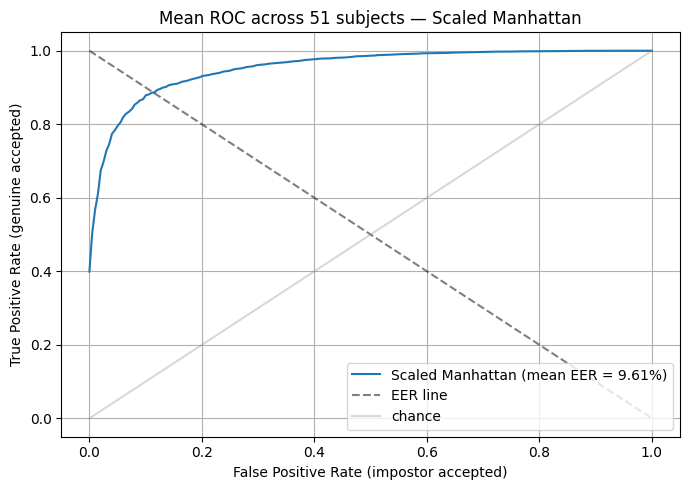

In [8]:
PRIMARY = "Scaled Manhattan"
train_fn, score_fn = DETECTORS[PRIMARY]

# Pool per-subject ROC points onto a common false-positive-rate grid, then average.
grid = np.linspace(0, 1, 200)
tpr_stack = []
for s in SUBJECTS:
    tr, gen, imp = get_splits(s)
    model = train_fn(tr)
    r = roc_and_eer(score_fn(model, gen), score_fn(model, imp))
    order = np.argsort(r["fpr"])
    tpr_stack.append(np.interp(grid, r["fpr"][order], r["tpr"][order]))
mean_tpr = np.mean(tpr_stack, axis=0)

mean_eer = results[PRIMARY].mean()
plt.plot(grid, mean_tpr, label=f"{PRIMARY} (mean EER = {mean_eer*100:.2f}%)")
plt.plot([0, 1], [1, 0], "k--", alpha=0.5, label="EER line")
plt.plot([0, 1], [0, 1], color="grey", alpha=0.3, label="chance")
plt.xlabel("False Positive Rate (impostor accepted)")
plt.ylabel("True Positive Rate (genuine accepted)")
plt.title(f"Mean ROC across {len(SUBJECTS)} subjects — {PRIMARY}")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Confusion matrix — primary detector at the EER operating point

Each subject's own EER threshold is applied to their genuine and impostor test vectors, and
the counts are aggregated across all 51 subjects. Genuine = the authorised user; Impostor =
an intruder typing the same password.

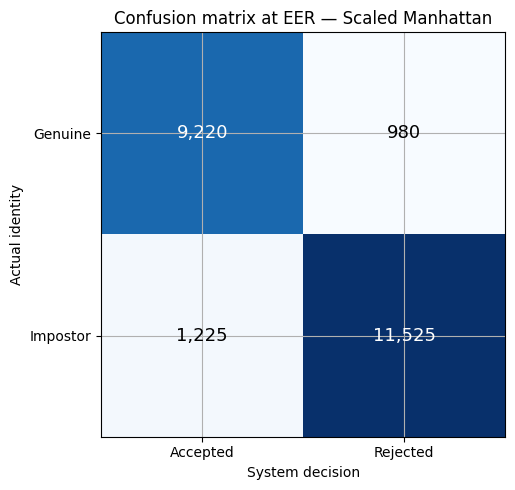

False Acceptance Rate (intruder let in): 9.61%
False Rejection Rate (legit user locked out): 9.61%


In [9]:
TP = FN = FP = TN = 0
for s in SUBJECTS:
    tr, gen, imp = get_splits(s)
    model = train_fn(tr)
    r = roc_and_eer(score_fn(model, gen), score_fn(model, imp))
    t = r["threshold"]
    gen_scores = score_fn(model, gen)
    imp_scores = score_fn(model, imp)
    TP += (gen_scores <= t).sum()   # genuine accepted
    FN += (gen_scores >  t).sum()   # genuine rejected  (locked out legit user)
    FP += (imp_scores <= t).sum()   # impostor accepted (missed intrusion)
    TN += (imp_scores >  t).sum()   # impostor rejected (intrusion caught)

cm = np.array([[TP, FN], [FP, TN]])
labels = ["Accepted", "Rejected"]

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Genuine", "Impostor"])
ax.set_xlabel("System decision"); ax.set_ylabel("Actual identity")
ax.set_title(f"Confusion matrix at EER — {PRIMARY}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=13,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

far = FP / (FP + TN)
frr = FN / (FN + TP)
print(f"False Acceptance Rate (intruder let in): {far*100:.2f}%")
print(f"False Rejection Rate (legit user locked out): {frr*100:.2f}%")

## 9. Summary

The Scaled Manhattan detector reproduces the benchmark result of Killourhy & Maxion (2009)
(≈9.6% mean EER), outperforming plain Manhattan and Euclidean and edging out the Nearest
Neighbour detector, while being cheaper to compute and store than a full per-subject
covariance model. This is why it is the primary matcher for both the offline benchmark and the
live Flask demo.

These figures belong to the **offline benchmark** subsection of Chapter 5. The live browser
demo is evaluated separately, because its millisecond-precision timers are not comparable to
the microsecond hardware clock behind this dataset.

---
# Extended analysis

The sections above reproduce the headline benchmark. The following analyses go
deeper into *why* the primary detector behaves as it does, and support the
discussion in Chapter 5:

10. Score separation — how far apart genuine and impostor scores sit
11. DET curve — the biometric-standard error trade-off view
12. Statistical significance — is Scaled Manhattan's advantage real?
13. Training-size sensitivity — how many enrollment samples are enough (this ties
    the offline benchmark to the live demo's sample count)
14. Per-subject difficulty — which users are easy or hard to verify


## 10. Score separation (primary detector)

For an anomaly detector, the EER is a symptom; the underlying cause is *how much
the genuine and impostor score distributions overlap*. Because Scaled Manhattan
scores are already MAD-normalised, they are broadly comparable across subjects,
so we pool every genuine and impostor test score and view the two distributions
together. The more they separate, the lower the achievable error.

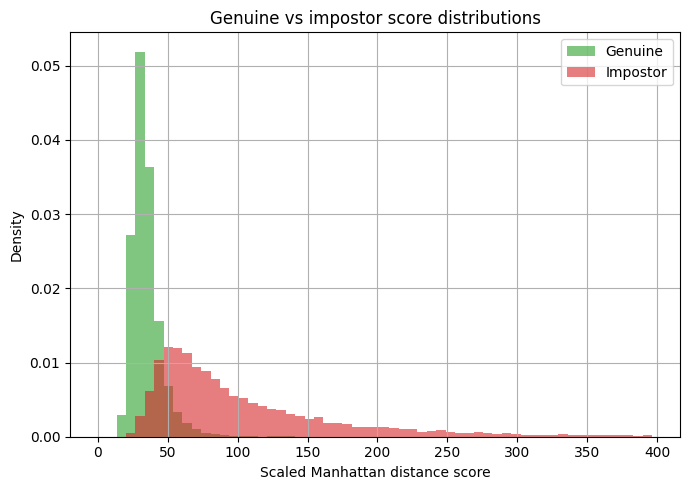

Genuine  mean =  34.76  (n=10200)
Impostor mean = 111.05  (n=12750)
Separation (Cohen's d) = 1.22  -- higher means easier to tell apart


In [10]:
gen_all, imp_all = [], []
for s in SUBJECTS:
    tr, gen, imp = get_splits(s)
    model = train_fn(tr)
    gen_all.append(score_fn(model, gen))
    imp_all.append(score_fn(model, imp))
gen_all = np.concatenate(gen_all)
imp_all = np.concatenate(imp_all)

hi = np.percentile(np.r_[gen_all, imp_all], 99)   # trim the long tail for the plot
bins = np.linspace(0, hi, 60)
plt.hist(gen_all, bins=bins, alpha=0.6, label="Genuine", color="#2ca02c", density=True)
plt.hist(imp_all, bins=bins, alpha=0.6, label="Impostor", color="#d62728", density=True)
plt.xlabel(f"{PRIMARY} distance score")
plt.ylabel("Density")
plt.title("Genuine vs impostor score distributions")
plt.legend()
plt.tight_layout()
plt.show()

# Simple, unit-free separation summary (Cohen's d).
d = (imp_all.mean() - gen_all.mean()) / np.sqrt((gen_all.var() + imp_all.var()) / 2)
print(f"Genuine  mean = {gen_all.mean():6.2f}  (n={len(gen_all)})")
print(f"Impostor mean = {imp_all.mean():6.2f}  (n={len(imp_all)})")
print(f"Separation (Cohen's d) = {d:.2f}  -- higher means easier to tell apart")

## 11. Detection Error Trade-off (DET) curve

The ROC plots acceptance against false alarms; the DET curve is the biometric
convention, plotting the two *error* rates against each other — miss rate (genuine
rejected) versus false-alarm rate (impostor accepted). A detector whose curve sits
closer to the origin is better, and the EER is where the curve meets the diagonal.
All four detectors are shown for comparison.

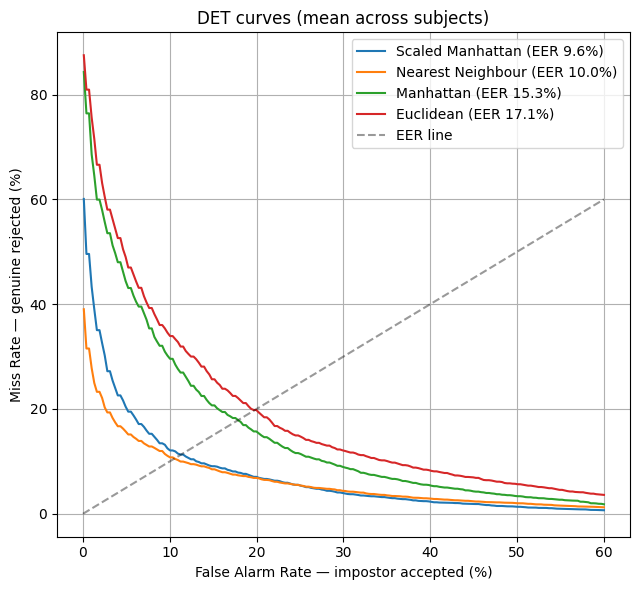

In [11]:
far_grid = np.linspace(0.001, 0.6, 200)

plt.figure(figsize=(6.5, 6))
for name, (tfn, sfn) in DETECTORS.items():
    frr_stack = []
    for s in SUBJECTS:
        tr, gen, imp = get_splits(s)
        model = tfn(tr)
        r = roc_and_eer(sfn(model, gen), sfn(model, imp))
        # r gives tpr/fpr; convert to miss (=1-tpr) as a function of fa (=fpr)
        miss = 1 - r["tpr"]; fa = r["fpr"]
        order = np.argsort(fa)
        frr_stack.append(np.interp(far_grid, fa[order], miss[order]))
    mean_frr = np.mean(frr_stack, axis=0)
    plt.plot(far_grid * 100, mean_frr * 100, label=f"{name} (EER {results[name].mean()*100:.1f}%)")

plt.plot([0, 60], [0, 60], "k--", alpha=0.4, label="EER line")
plt.xlabel("False Alarm Rate — impostor accepted (%)")
plt.ylabel("Miss Rate — genuine rejected (%)")
plt.title("DET curves (mean across subjects)")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Is the difference statistically significant?

Scaled Manhattan has the lowest mean EER, but each detector produces 51 per-subject
EERs, so we can test whether its advantage is systematic rather than luck. The
Wilcoxon signed-rank test is a paired, non-parametric test — appropriate here
because the same 51 subjects are scored by every detector and EERs are not
normally distributed. A small p-value means the paired differences are consistently
in Scaled Manhattan's favour.

In [12]:
try:
    from scipy.stats import wilcoxon
    have_scipy = True
except Exception:
    have_scipy = False
    print("scipy not available -- reporting win counts only")

primary = results[PRIMARY]
rows = []
for name, eers in results.items():
    if name == PRIMARY:
        continue
    wins = int((primary < eers).sum())          # subjects where primary is better
    row = {"vs Detector": name,
           f"{PRIMARY} lower on": f"{wins}/{len(primary)} subjects",
           "mean EER diff (pp)": round((eers.mean() - primary.mean()) * 100, 2)}
    if have_scipy:
        stat, p = wilcoxon(primary, eers)
        row["p-value"] = f"{p:.2e}"
    rows.append(row)

pd.DataFrame(rows)

,vs Detector,Scaled Manhattan lower on,mean EER diff (pp),p-value
0,Nearest Neighbour,25/51 subjects,0.35,4.70e-01
1,Manhattan,46/51 subjects,5.68,7.71e-09
2,Euclidean,46/51 subjects,7.45,2.13e-08


## 13. How many enrollment samples are enough?

The benchmark trains on 200 repetitions, but the live demo asks a user to type only
a handful of times. This analysis varies the number of training repetitions and
measures the effect on the primary detector's EER, holding the genuine and impostor
test sets fixed. It shows where accuracy plateaus — the justification for the demo's
enrollment length.

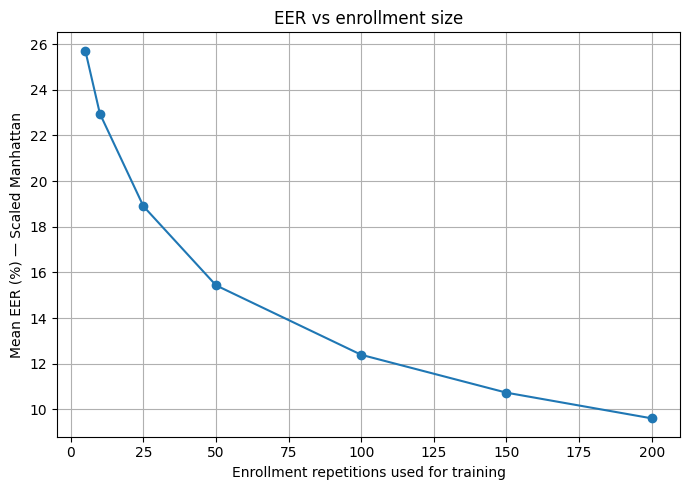

    5 reps -> 25.71% EER
   10 reps -> 22.96% EER
   25 reps -> 18.90% EER
   50 reps -> 15.43% EER
  100 reps -> 12.39% EER
  150 reps -> 10.73% EER
  200 reps ->  9.61% EER


In [13]:
def evaluate_with_train_size(n_train):
    eers = []
    for s in SUBJECTS:
        tr_full = df[(df.subject == s) & (df.sessionIndex <= 4)][FEATURES].values
        tr = tr_full[:n_train]
        gen = df[(df.subject == s) & (df.sessionIndex > 4)][FEATURES].values
        imp = df[(df.subject != s) & (df.sessionIndex == 1) & (df.rep <= 5)][FEATURES].values
        model = train_fn(tr)
        eers.append(roc_and_eer(score_fn(model, gen), score_fn(model, imp))["eer"])
    return np.mean(eers)

sizes = [5, 10, 25, 50, 100, 150, 200]
curve = [evaluate_with_train_size(n) * 100 for n in sizes]

plt.plot(sizes, curve, marker="o")
plt.xlabel("Enrollment repetitions used for training")
plt.ylabel(f"Mean EER (%) — {PRIMARY}")
plt.title("EER vs enrollment size")
plt.tight_layout()
plt.show()

for n, e in zip(sizes, curve):
    print(f"  {n:3d} reps -> {e:5.2f}% EER")

The steepest gains come before roughly 50 repetitions, but the EER keeps
falling across the whole range — from about 26% at 5 reps to 9.6% at 200 — so more
enrollment data genuinely helps rather than plateauing early. Two caveats matter
for interpreting this against the live demo. First, this curve is *cross-session*:
training and test data come from different sittings, so session-to-session drift
inflates the error at low sample counts. The live demo enrolls and verifies in a
single sitting, where a short enrollment performs considerably better than this
curve implies. Second, the offline benchmark deliberately uses the full 200
repetitions for comparability with the published literature. The demo's shorter
enrollment is therefore a usability trade-off, not a claim of equal accuracy.

## 14. Per-subject difficulty

Averages hide variation between users. Some subjects have a highly consistent
typing rhythm (low EER); others are inherently harder to verify. The box plot shows
the spread of per-subject EERs for each detector, and the table lists the easiest
and hardest subjects for the primary detector.

/tmp/ipykernel_634/1406324056.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(DETECTORS.keys()), vert=True)


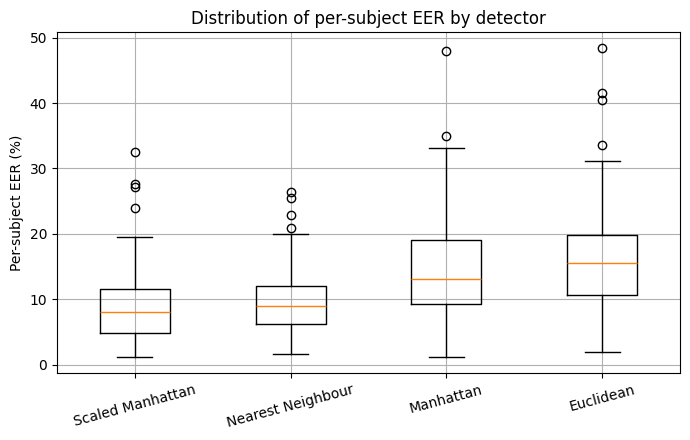

,EER (%),rank
s036,1.10,easiest
s055,1.55,easiest
s052,1.55,easiest
s032,27.10,hardest
s031,27.55,hardest
s047,32.45,hardest


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [results[n] * 100 for n in DETECTORS]
ax.boxplot(data, labels=list(DETECTORS.keys()), vert=True)
ax.set_ylabel("Per-subject EER (%)")
ax.set_title("Distribution of per-subject EER by detector")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

per_subj = pd.Series(results[PRIMARY] * 100, index=SUBJECTS).sort_values()
summary_tbl = pd.concat([
    per_subj.head(3).rename("EER (%)").to_frame().assign(rank="easiest"),
    per_subj.tail(3).rename("EER (%)").to_frame().assign(rank="hardest"),
]).round(2)
summary_tbl

## 15. Extended summary

Scaled Manhattan separates genuine from impostor typing with a large effect size
(Cohen's d ≈ 1.2). Its EER advantage over the plain Manhattan and Euclidean
baselines is statistically significant across the 51 subjects, not an artefact of
averaging; against the Nearest Neighbour detector, however, the two are
statistically indistinguishable, so Scaled Manhattan is preferred on the secondary
grounds of being cheaper to compute and store rather than on accuracy alone.
Accuracy improves with enrollment size across the whole tested range, with the
largest gains before ~50 repetitions. Per-subject variation is substantial — the
best subject's EER is under 2% while the hardest exceeds 30% — so real deployments
benefit from per-user thresholds (as the live demo uses) rather than one global
cut-off.

As before, these results belong to the **offline benchmark** and are reported
separately from the live browser demo.